# Deep Neural Networks (PyTorch)

We're going to spend today walking through [PyTorch](https://pytorch.org), a popular open-source library for deep learning. We're talking about PyTorch because I prefer it. Others prefer TensorFlow, but that number is dwindling. Others prefer JAX, particularly in the research community, but it's a small fraction. 

In general, PyTorch has good documentation, good built-in functionality, and a wide network of compatible libraries that make Deep Learning easier to get up and running. It also exposes a bit more of the machinery to the user which makes it more customizable, particularly for things that aren't vanilla supervised learning.

There are some subtle under-the-hood differences between PyTorch and TensorFlow. I may get into those details next time, or maybe not.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


## PyTorch Tensors

The basic unit of operation in (py)torch is a **tensor**. A **scalar** is a rank-0 tensor. It has no index. A **vector** is a rank-1 tensor that can be indexed as $\vec{V}: V_i$. A **matrix** is a rank-2 tensor that can be indexed as $\overleftrightarrow{M}: M_{ij}$. A rank-3 tensor is similarly indexed as $T_{ijk}$.

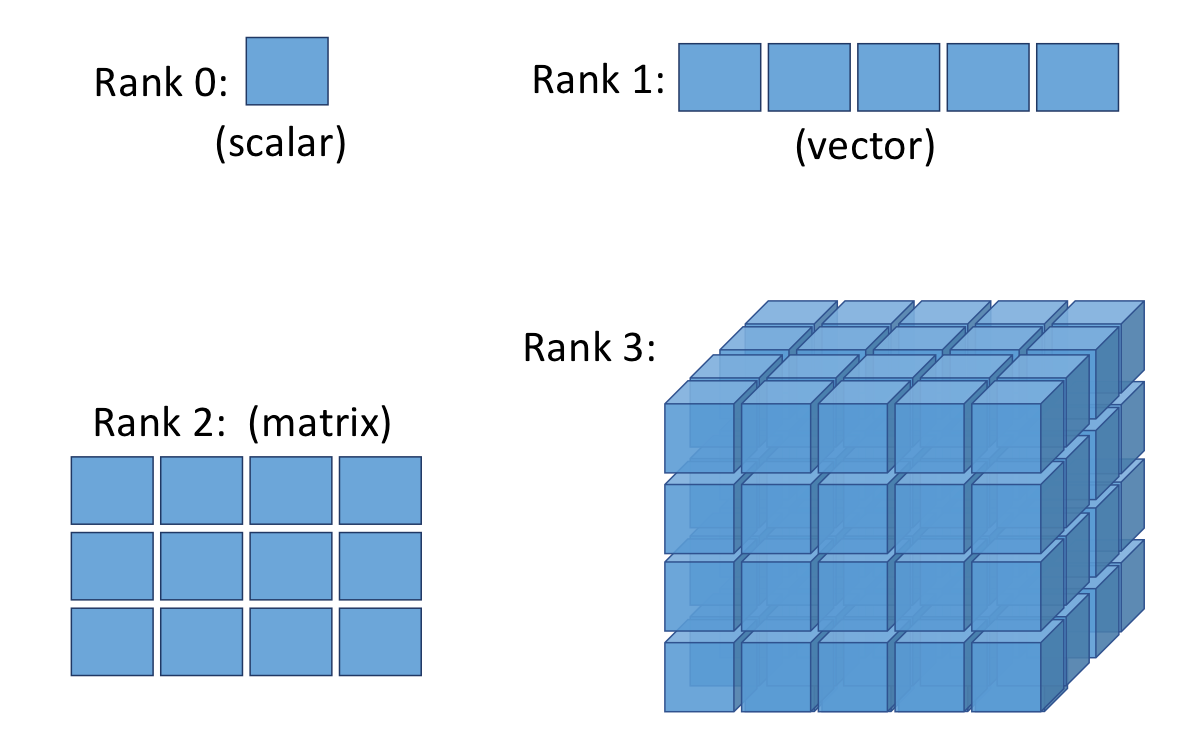

In [4]:
import numpy as np
a1 = [1, 2, 3]
a2 = np.array([1, 2, 3], dtype=np.float32)

# Turn these into torch tensors
t1 = torch.tensor(a1)
t2 = torch.tensor(a2)

print(t1)
print(t2)

tensor([1, 2, 3])
tensor([1., 2., 3.])


In [7]:
# Tensors are a lot like numpy ndarrays
a3 = np.eye(3, dtype=np.float32)
print(a3)
print('nd-array attributes:', a3.shape, a3.dtype)

# Turn this into a torch tensor and print out some attributes
t3 = torch.from_numpy(a3)
print(t3)
print('tensor attributes:', t3.shape, t3.dtype, t3.device, t3.grad, t3.grad_fn)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
nd-array attributes: (3, 3) float32
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
tensor attributes: torch.Size([3, 3]) torch.float32 cpu None None


In [8]:
# tensor operations

# Resize
t3_1 = t3.reshape([9,])
print(t3_1)

# Data type conversion
t3_2 = t3.bool()
print(t3_2)

# Send to other device
t3_3 = t3.to(device)
print(t3_3)

tensor([1., 0., 0., 0., 1., 0., 0., 0., 1.])
tensor([[ True, False, False],
        [False,  True, False],
        [False, False,  True]])
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], device='cuda:0')


### Big Tensors

Tensors can get very large and have a large number of indices. For example, a batch of images might have 4 indices: $[B, C, H, W]$

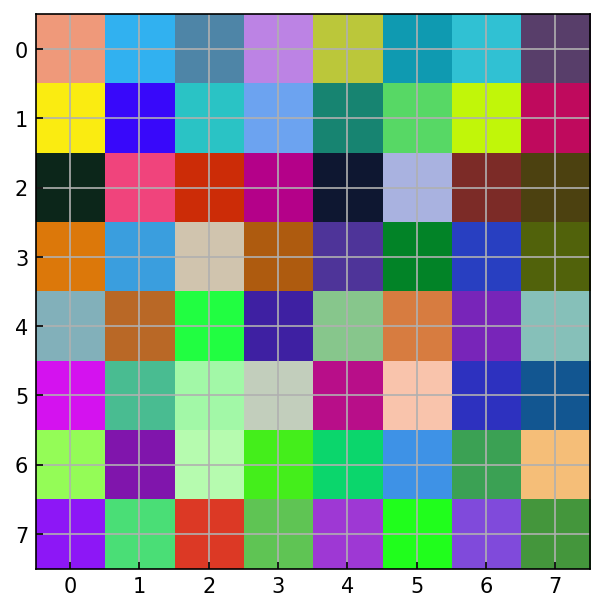

In [9]:
t_big = torch.rand(1, 3, 8, 8)

%matplotlib inline
import matplotlib.pyplot as plt
ax = plt.figure().gca()
ax.imshow(t_big.squeeze().permute(1, 2, 0))

### Fun with tensors

We can do a lot of normal mathematical and array operations with tensors just as we would numpy arrays

In [61]:
t1 = torch.rand(3, 2)
t2 = torch.normal(mean=0, std=1, size=(3, 2))

# Elementwise product
t3 = t1 * t2
print('Elementwise product', t3.shape, '\n', t3)

# Mean along dimension
print()
t4 = t2.mean(dim=1)
print('Dimension mean', t4.shape, '\n', t4)

# Matrix multiplication
print()
t5 = t1.T @ t2
print('Matrix multiplication', t5.shape, '\n', t5)

# L2 Norm
print()
t6 = torch.linalg.norm(t2)
print('L2 norm', t6.shape, '\n', t6)

Elementwise product torch.Size([3, 2]) 
 tensor([[-0.2361,  0.2343],
        [-0.0146, -0.1759],
        [ 0.0013,  0.4561]])

Dimension mean torch.Size([3]) 
 tensor([ 0.5628, -0.4950,  0.5481])

Matrix multiplication torch.Size([2, 2]) 
 tensor([[-0.2494,  0.9297],
        [-0.0945,  0.5145]])

L2 norm torch.Size([]) 
 tensor(2.0279)


In [12]:
print('For elements t1:', t1.shape, 'and t2:', t2.shape)

# Tensor concatenation
print()
t3 = torch.concat([t1, t2], dim=1)
print('concat(t1, t2):', t3.shape)

# Tensor splitting
print()
t4, t5 = torch.split(t3, 2, dim=1)
print('split t3 at index 2 on dimension 1:')
print('\tFirst part', t4.shape, ' = t1?', torch.all(t1 == t4))
print('\tSecond part', t5.shape, '= t2?', torch.all(t2 == t5))

# Tensor stacking
print()
t6 = torch.stack([t1, t2], dim=0)
print('stack(t1, t2):', t6.shape)

For elements t1: torch.Size([3, 2]) and t2: torch.Size([3, 2])

concat(t1, t2): torch.Size([3, 4])

split t3 at index 2 on dimension 1:
	First part torch.Size([3, 2])  = t1? tensor(True)
	Second part torch.Size([3, 2]) = t2? tensor(True)

stack(t1, t2): torch.Size([2, 3, 2])


## Torch Datasets and DataLoaders

Torch builds in a lot of functionality that we need for training neural networks beyond the networks themselves (which we will get to). For example, data loading pipelines to serve tensors to the model during training

In [13]:
from torch.utils.data import Dataset
class BasicDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def __len__(self):
        """ So torch code knows how many examples to fetch from the dataset """
        return self.x.shape[0]

    def __getitem__(self, idx):
        """ So torch code knows how to access the underlying data """
        return self.x[idx], self.y[idx]

# A torch Dataset can be accessed just like an array now
dataset = BasicDataset(
    x=torch.rand([10, 4]),
    y=torch.arange(10, dtype=torch.long)
)

print(f"The size of the dataset is {len(dataset)}")
print(f"The 4th element of the dataset is {dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.3435, 0.9975, 0.9190, 0.2902]), tensor(3))


In [14]:
from torch.utils.data import TensorDataset
tensor_dataset = TensorDataset(dataset.x, dataset.y)
print(f"The size of the dataset is {len(tensor_dataset)}")
print(f"The 4th element of the dataset is {tensor_dataset[3]}")

The size of the dataset is 10
The 4th element of the dataset is (tensor([0.3435, 0.9975, 0.9190, 0.2902]), tensor(3))


In [15]:
from torch.utils.data import DataLoader

# Initialize a loader
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Iterate through the loader
for batch in loader:
    xb, yb = batch
    print(xb, yb)

tensor([[0.4534, 0.6300, 0.9348, 0.2578],
        [0.3435, 0.9975, 0.9190, 0.2902]]) tensor([5, 3])
tensor([[0.5138, 0.6810, 0.6457, 0.4596],
        [0.3279, 0.2641, 0.9320, 0.7317]]) tensor([8, 4])
tensor([[0.6127, 0.4610, 0.6037, 0.4665],
        [0.5685, 0.3027, 0.5005, 0.8539]]) tensor([6, 2])
tensor([[0.3141, 0.1604, 0.8766, 0.3808],
        [0.4338, 0.2068, 0.2350, 0.5458]]) tensor([1, 0])
tensor([[0.6643, 0.5483, 0.2717, 0.7406],
        [0.7640, 0.4157, 0.3335, 0.7619]]) tensor([9, 7])


In [16]:
# Iterate through multiple epochs
for epoch in range(2):
    print()
    # Iterate through the loader
    for batch in loader:
        xb, yb = batch
        print(xb, yb)


tensor([[0.4338, 0.2068, 0.2350, 0.5458],
        [0.3279, 0.2641, 0.9320, 0.7317]]) tensor([0, 4])
tensor([[0.6643, 0.5483, 0.2717, 0.7406],
        [0.6127, 0.4610, 0.6037, 0.4665]]) tensor([9, 6])
tensor([[0.3435, 0.9975, 0.9190, 0.2902],
        [0.7640, 0.4157, 0.3335, 0.7619]]) tensor([3, 7])
tensor([[0.3141, 0.1604, 0.8766, 0.3808],
        [0.5685, 0.3027, 0.5005, 0.8539]]) tensor([1, 2])
tensor([[0.4534, 0.6300, 0.9348, 0.2578],
        [0.5138, 0.6810, 0.6457, 0.4596]]) tensor([5, 8])

tensor([[0.4534, 0.6300, 0.9348, 0.2578],
        [0.3435, 0.9975, 0.9190, 0.2902]]) tensor([5, 3])
tensor([[0.7640, 0.4157, 0.3335, 0.7619],
        [0.6127, 0.4610, 0.6037, 0.4665]]) tensor([7, 6])
tensor([[0.5138, 0.6810, 0.6457, 0.4596],
        [0.3141, 0.1604, 0.8766, 0.3808]]) tensor([8, 1])
tensor([[0.3279, 0.2641, 0.9320, 0.7317],
        [0.5685, 0.3027, 0.5005, 0.8539]]) tensor([4, 2])
tensor([[0.4338, 0.2068, 0.2350, 0.5458],
        [0.6643, 0.5483, 0.2717, 0.7406]]) tensor([0, 9]

### Multiprocessing while data loading

In [17]:
import os
print(f'Environment has {os.cpu_count()} available cores')

Environment has 32 available cores


In [18]:
dataset = TensorDataset(
    torch.rand([8192, 3, 128, 128]),
    torch.arange(8192, dtype=torch.long)
)
print(len(dataset))

8192


In [19]:
from time import time

# Create a loader with batch_size 32, no multi-processing
loader = DataLoader(dataset, batch_size=32, num_workers=0)

# Iterate through the loader and time each epoch
for epoch in range(2):
    t = time()
    for batch in loader:
        a = len(batch[0])
    print('Epoch', epoch, 'time = ', time()-t, 's')

Epoch 0 time =  3.0815794467926025 s
Epoch 1 time =  2.897569179534912 s


In [20]:
from time import time

# Create a loader with batch_size 32, num_workers > 0
loader = DataLoader(dataset, batch_size=32, num_workers=2)

# Iterate through the loader and time each epoch
for epoch in range(2):
    t = time()
    for batch in loader:
        a = len(batch[0])
    print('Epoch', epoch, 'time = ', time()-t, 's')

Epoch 0 time =  1.189521312713623 s
Epoch 1 time =  1.289581537246704 s


## Gradient descent

### Linear regression

Just as a teaser, let's see how to do regression using gradient descent and PyTorch. Start by creating a dataset in numpy

[Text(0.5, 0, 'x'), Text(0, 0.5, 'y')]

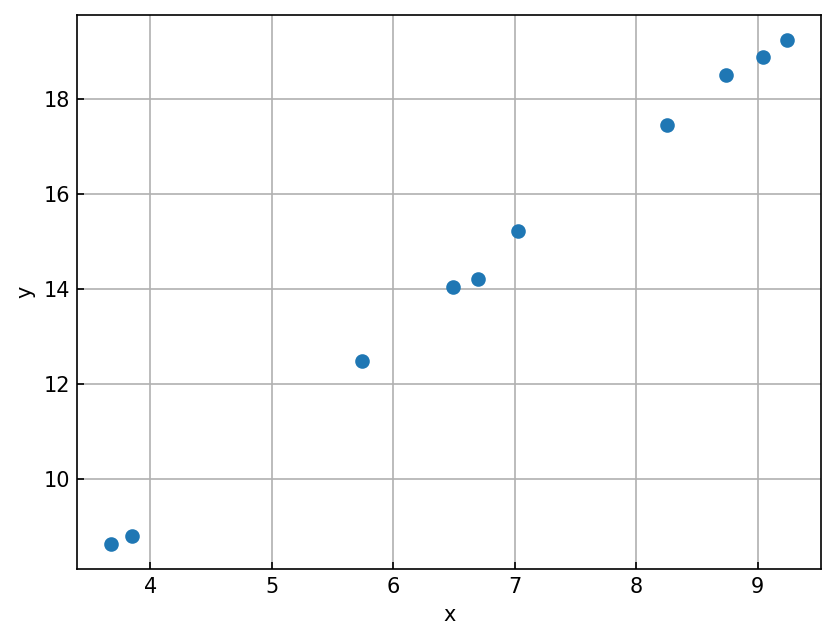

In [43]:
X = np.random.uniform(size=(10, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.25, size=X.shape).astype(np.float32)

y = 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

In [44]:
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays into torch tensors
X_train = torch.from_numpy(X)
y_train = torch.from_numpy(y)

# A TensorDataset holds the torch tensors
train_dataset = TensorDataset(X_train, y_train)

# A dataloader serves up the data to the model
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [45]:
def mse_loss(y_true, y_pred):
    """ Loss function """
    # np.power(y_true - y_pred, 2).mean()
    return (y_true - y_pred).pow(2).mean()

def model(x):
    """ Model is linear equation """
    return x @ slope + intercept

# Initialize model weights
slope = torch.randn(1)
slope.requires_grad_()
intercept = torch.zeros(1, requires_grad=True)

slope, intercept

(tensor([0.3008], requires_grad=True), tensor([0.], requires_grad=True))

In [46]:
lr = 0.01 # Learning rate
num_epochs = 100 # Run for 100 epochs
log_epochs = 10 # Print out loss every 10 epochs

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        # Make a prediction
        y_pred = model(x_batch)

        # Compute the loss
        loss = mse_loss(y_pred, y_batch)
        
        # Compute and backpropagate gradients
        loss.backward()

        # Apply the weight updates
        with torch.no_grad():
            slope -= lr * slope.grad
            intercept -= lr * intercept.grad

            slope.grad.zero_()
            intercept.grad.zero_()

        # Update the running loss tally
        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 241.286
Epoch 10: loss = 2.707
Epoch 20: loss = 1.631
Epoch 30: loss = 0.774
Epoch 40: loss = 1.041
Epoch 50: loss = 1.172
Epoch 60: loss = 0.719
Epoch 70: loss = 0.959
Epoch 80: loss = 0.968
Epoch 90: loss = 0.427


Fit parameters: slope = 1.983, intercept = 1.113


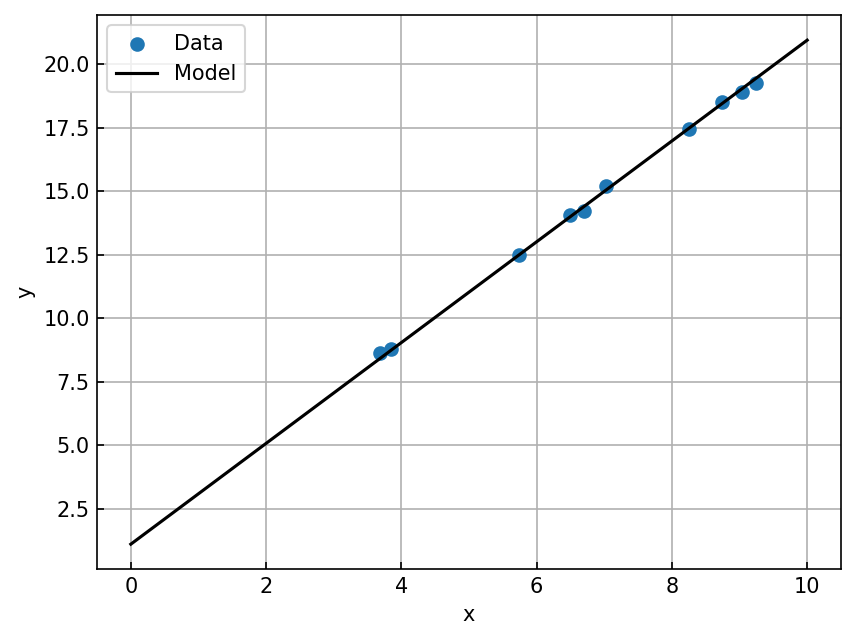

In [47]:
print(f"Fit parameters: slope = {slope.item():.3f}, intercept = {intercept.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

xx = torch.linspace(0, 10, 5, dtype=torch.float32, requires_grad=False)
yy = model(xx[:, None])
ax.plot(xx.numpy(), yy.detach().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

#### How does this work?

PyTorch stores an attribute alongside each tensor called `grad`. We'll talk about this next class in more detail. But in a nutshell, this piece is populated when we call `backward()` after making the forward pass. 

In [48]:
# Initialize the model weights
slope = torch.randn(1, requires_grad=True)
intercept = torch.zeros(1, requires_grad=True)

for x_batch, y_batch in train_loader:
    print(slope.grad, intercept.grad, slope.grad_fn)

    y_pred = model(x_batch)
    print(slope.grad, intercept.grad, y_pred.grad_fn)

    loss = mse_loss(y_batch, y_pred)
    print(slope.grad, intercept.grad, loss.grad_fn)

    loss.backward() # This computes the gradients for our relevant tensors
    print(slope.grad, intercept.grad)

    break

None None None
None None <AddBackward0 object at 0x7fef9041a0e0>
None None <MeanBackward0 object at 0x7fef9041a0e0>
tensor([-315.5576]) tensor([-44.9250])


#### A more `PyTorch` way of doing it

In [49]:
from torch.nn import Linear, MSELoss
from torch.optim import SGD

# Create a nn.Linear model that maps x -> y with a bias term
model = Linear(1, 1, bias=True)

# Put the model on the hardware accelerator (GPU, TPU, etc.)
model = model.to(device)

# Use MSE Loss in torch
loss_fn = MSELoss()

# Compute weight updates using stochastic gradient descent
optimizer = SGD(model.parameters(), lr=0.01)

for epoch in range(num_epochs):
    epoch_loss = 0.
    for x_batch, y_batch in train_loader:
        # Send x, y to the model device
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Make the prediction
        y_pred = model(x_batch)
        # Compute the loss
        loss = loss_fn(y_pred, y_batch)

        # Compute and backpropagate the gradients
        loss.backward()

        # Apply the weight updates using the optimizer
        optimizer.step()

        # Zero out the gradients for the next pass
        optimizer.zero_grad()

        epoch_loss += loss.item()

    if epoch % log_epochs == 0:
        print(f"Epoch {epoch}: loss = {epoch_loss:.3f}")

Epoch 0: loss = 146.644
Epoch 10: loss = 1.907
Epoch 20: loss = 1.554
Epoch 30: loss = 2.575
Epoch 40: loss = 1.469
Epoch 50: loss = 0.659
Epoch 60: loss = 1.175
Epoch 70: loss = 0.465
Epoch 80: loss = 0.776
Epoch 90: loss = 0.571


Fit parameters: slope = 2.032, intercept = 1.036


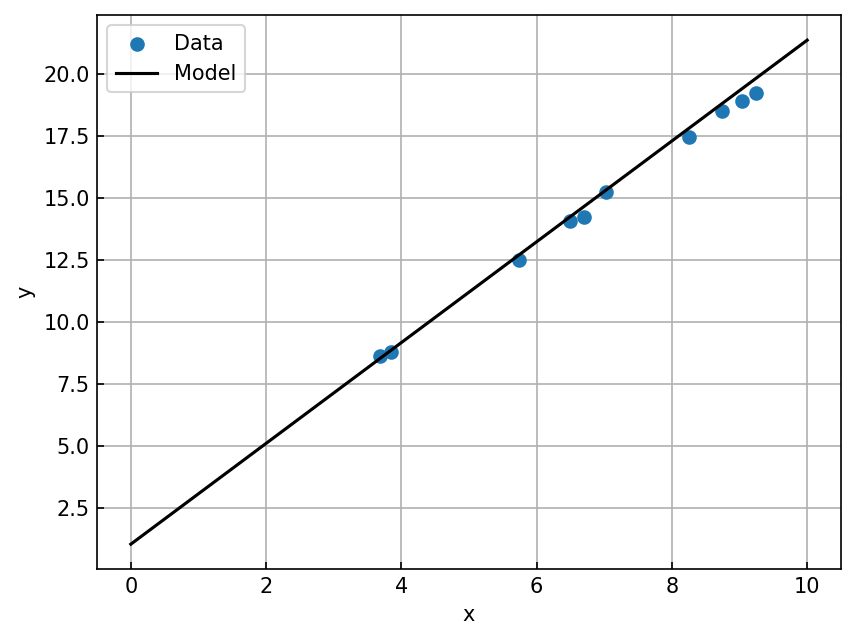

In [50]:
print(f"Fit parameters: slope = {model.weight.item():.3f}, intercept = {model.bias.item():.3f}")

ax = plt.figure().gca()
ax.scatter(X, y, label='Data')

with torch.no_grad():
    xx = torch.linspace(0, 10, 5, dtype=torch.float32, device=device)
    yy = model(xx[:, None])[:, 0]
    ax.plot(xx.cpu().numpy(), yy.cpu().numpy(), color='black', label='Model')

ax.set(xlabel='x', ylabel='y');
ax.legend()

### Polynomial regression

How would you implement a model to fit the following dataset?

In [ ]:
X = np.random.uniform(size=(32, 1)).astype(np.float32) * 10
noise = np.random.normal(0, 0.5, size=X.shape).astype(np.float32)

y = 0.5 * X**2 + 2. * X + 1. + noise

ax = plt.figure().gca()
ax.scatter(X, y)
ax.set(xlabel='x', ylabel='y')

## Neural networks

Let's train a neural network to fit the XOR dataset

### Dataset creation

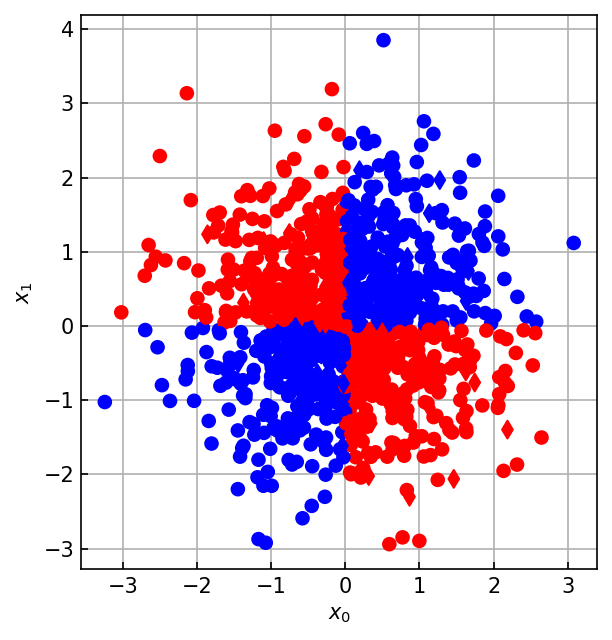

In [51]:
def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.randn(N, 2).astype(np.float32)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X, y = make_xor_dataset(N=1024, random_seed=42)
X_test, y_test = make_xor_dataset(N=64, random_seed=1)

ax = plt.figure().gca()
ax.scatter(X[:, 0], X[:, 1], c=y, marker='o', cmap='bwr')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='d', cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal');

In [52]:
from torch.utils.data import TensorDataset, DataLoader, random_split

# Create a TensorDataset
train_val_dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

# Perform a train/validation split
train_dataset, val_dataset = random_split(train_val_dataset, [0.8, 0.2])

# Create a test dataset as well
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 820, Val: 204, Test: 64


### Model implementation

In [53]:
import torch.nn as nn
# Create a model using torch.nn.Sequential
model = nn.Sequential(
    nn.Linear(2, 128),
    nn.Sigmoid(),
    nn.Linear(128, 2)
)
model

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=128, out_features=2, bias=True)
)

In [57]:
import torch.nn as nn
import torch.nn.functional as F

# Create a model by extending torch.nn.Module
class Model(torch.nn.Module):
    """ A torch.nn.Module object implements a forward pass
        Torch, under the hood, takes care of everything else
    """
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden(x)
        x = F.sigmoid(x)
        x = self.output(x)
        return x

model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)
model

Model(
  (hidden): Linear(in_features=2, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=2, bias=True)
)

### Training loop

In [58]:
from tqdm import tqdm, trange

def train(model, loss_fn, optimizer, train_dataset, val_dataset, batch_size=32, max_epochs=100):
    train_loss, train_acc = [], []
    val_loss, val_acc = [], []

    # Create dataloaders for train/validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    pbar_epoch = trange(num_epochs)
    for ii in pbar_epoch:
        train_loss_ = 0.
        train_acc_ = 0.
        for x, y, in train_loader:
            # Send x, y to GPU/TPU/etc.
            x = x.to(device)
            y = y.to(device)

            # Make a prediction, compute the loss
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # Backpropagate gradients, apply weight updates, reset gradients
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Logging
            train_loss_ += loss.item() * x.shape[0]
            train_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

        train_loss.append(train_loss_ / len(train_dataset))
        train_acc.append(train_acc_ / len(train_dataset))

        val_loss_ = 0.
        val_acc_ = 0.
        with torch.no_grad():
            for x, y, in val_loader:
                # Send x, y to GPU/TPU/etc.
                x = x.to(device)
                y = y.to(device)
    
                # Make a prediction, compute the loss
                y_pred = model(x)
                loss = loss_fn(y_pred, y)
        
                # Logging
                val_loss_ += loss.item() * x.shape[0]
                val_acc_  += (torch.argmax(y_pred, dim=1) == y).float().sum().item()

            val_loss.append(val_loss_ / len(val_dataset))
            val_acc.append(val_acc_ / len(val_dataset))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {num_epochs:03d}",
            train_loss=f"{train_loss[-1]:.3f}",
            train_acc=f"{train_acc[-1]:.3f}",
            val_loss=f"{val_loss[-1]:.3f}",
            val_acc=f"{val_acc[-1]:.3f}")

    return model, (train_loss, train_acc, val_loss, val_acc)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
model, model_stats = train(model, loss_fn, optimizer, train_dataset, val_dataset)

100%|██████████| 100/100 [00:03<00:00, 30.01it/s, epoch=100 / 100, train_acc=0.962, train_loss=0.208, val_acc=0.926, val_loss=0.231]


### Analysis

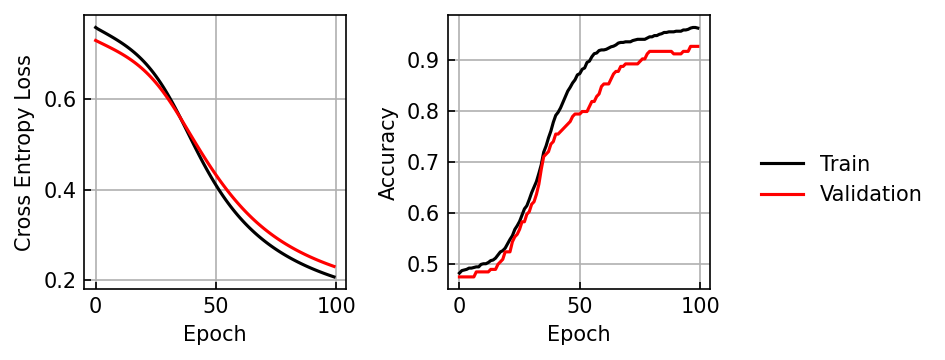

In [59]:
def loss_accuracy_plot(train_loss, train_acc, val_loss, val_acc):
    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

    ax[0].plot(train_loss, color='black', label='Train')
    ax[0].plot(val_loss, color='red', label='Validation')
    ax[0].set(xlabel='Epoch', ylabel='Cross Entropy Loss')

    ax[1].plot(train_acc, color='black', label='Train')
    ax[1].plot(val_acc, color='red', label='Validation')
    ax[1].set(xlabel='Epoch', ylabel='Accuracy')

    fig.legend(*ax[1].get_legend_handles_labels(), 
            loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)
    return fig

loss_accuracy_plot(*model_stats)
plt.tight_layout()

<Axes: >

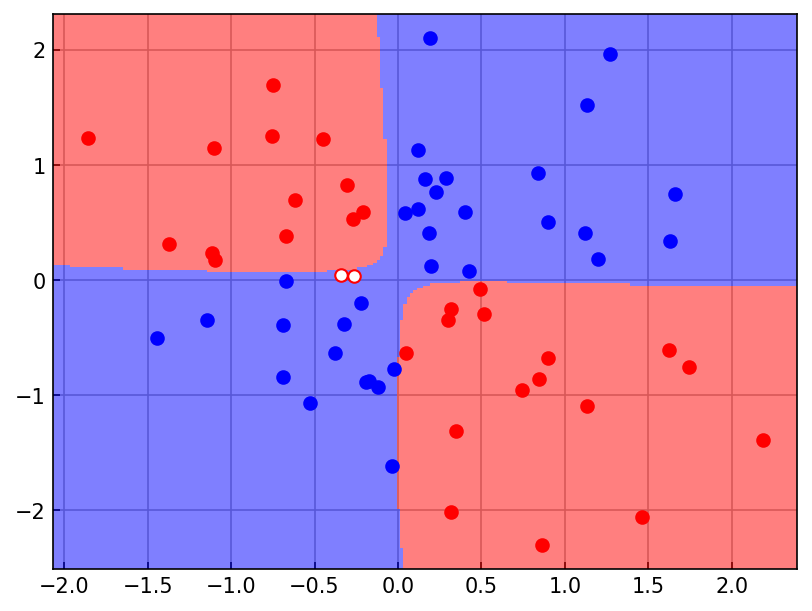

In [60]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    with torch.no_grad():
        x_grid = np.stack([x1.ravel(), x2.ravel()]).T
        x_grid = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        y_model = model(x_grid).cpu().numpy()
        y_model = np.argmax(y_model, axis=-1)
        y_model = y_model.reshape(x1.shape)

        y_pred = model(torch.from_numpy(X).to(device)).cpu().numpy()
        y_pred = np.argmax(y_pred, axis=1)

        pred_mask = y_pred == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)

## Activation functions

In [ ]:
class LinearModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()

    def forward(self, x):

class TanhModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()

    def forward(self, x):

class ReLUModel(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()

    def forward(self, x):

In [ ]:
for label, model_type in zip(['Linear', 'Tanh', 'ReLU'],
                             [LinearModel, TanhModel, ReLUModel]):
    model = model_type(
        input_size=X.shape[1],
        hidden_size=128,
        output_size=2, # 2 classes
    ).to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model, model_stats= train(model, loss_fn, optimizer, train_loader, val_loader)
    fig = loss_accuracy_plot(*model_stats)
    fig.suptitle(label + " Activation")
    plt.tight_layout()

    ax = plt.figure().gca()
    plot_decision_boundary(ax, X_test, y_test, model)
    ax.set_title(label + " Activation")
    plt.show()

## Deep MLP

In [62]:
class DeepMLP(torch.nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.hidden1 = nn.Linear(input_size, hidden_size)
        self.hidden2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden1(x)
        x = F.relu(x)
        x = self.hidden2(x)
        x = F.relu(x)
        x = self.output(x)
        return x


model = Model(
    input_size=X.shape[1],
    hidden_size=128,
    output_size=2, # 2 classes
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

Model(
  (hidden): Linear(in_features=2, out_features=128, bias=True)
  (output): Linear(in_features=128, out_features=2, bias=True)
)

100%|██████████| 100/100 [00:03<00:00, 25.97it/s, epoch=100 / 100, train_acc=0.968, train_loss=0.219, val_acc=0.946, val_loss=0.229]


<Axes: >

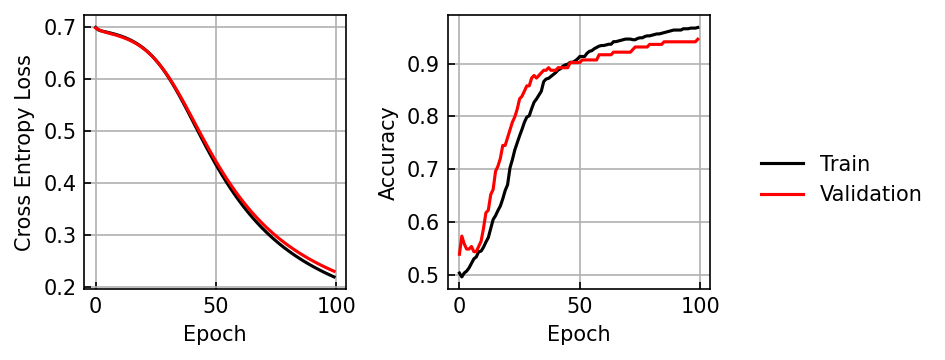

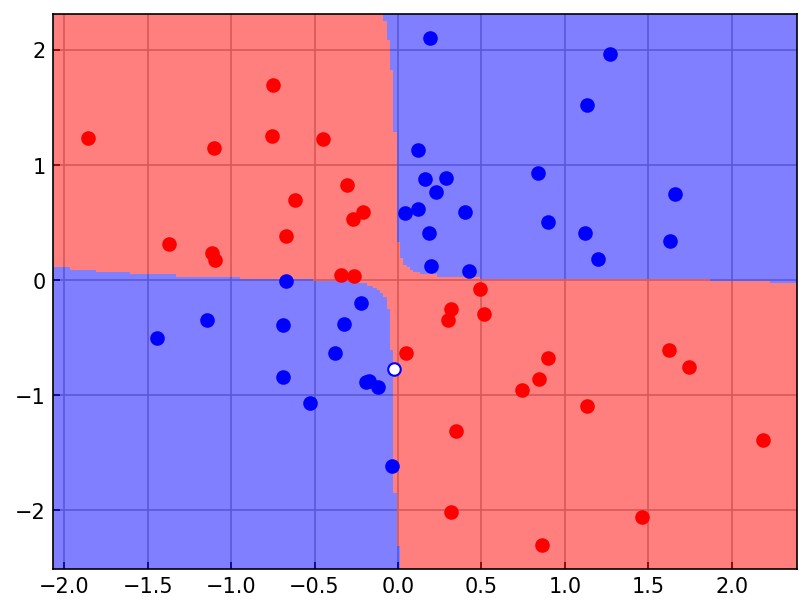

In [63]:
model, model_stats= train(model, loss_fn, optimizer, train_dataset, val_dataset)
loss_accuracy_plot(*model_stats)
plt.tight_layout()

ax = plt.figure().gca()
plot_decision_boundary(ax, X_test, y_test, model)